## Ejemplo práctico: Entrenamiento del modelo

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 1) Crear datos de ejemplo
datos = pd.DataFrame({
    "Horas_Estudio": [1, 2, 3, 4, 5],
    "Calificacion":  [45, 50, 65, 70, 85]
})

# 2) Separar variables
X = datos[["Horas_Estudio"]]
y = datos["Calificacion"]

# 3) Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

# 4) Crear y entrenar el modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# 5) Ver coeficientes del modelo
print("Intercepto (β0):", modelo.intercept_)
print("Coeficiente (β1):", modelo.coef_[0])

# 6) Evaluación con R²
r2 = modelo.score(X_test, y_test)
print("R²:", r2)

Intercepto (β0): 37.14285714285715
Coeficiente (β1): 8.57142857142857
R²: 0.9291961682632236


In [2]:
# Realizar predicción para 3.5 horas de estudio
horas_nuevas = [[3.5]]
calificacion_predicha = modelo.predict(horas_nuevas)
print(f"Calificación predicha: {calificacion_predicha[0]:.2f}")
print(f"R² del modelo: {modelo.score(X_test, y_test):.2f}")

Calificación predicha: 67.14
R² del modelo: 0.93


d:\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## Live Coding 1

1. Generar y Cargar dataset (auto-mpg.csv)


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

cols_num = [
    "mpg", "cylinders", "displacement", "horsepower",
    "weight", "acceleration", "model_year", "origin"
]

# Lee 8 columnas por espacios + todo lo demás como el nombre (puede venir con espacios)
df = pd.read_csv(
    url,
    sep=r"\s+",
    names=cols_num + ["car_name"],
    na_values="?",
    engine="python",
    usecols=list(range(9)),          # asegura 9 columnas: 8 + 1 (resto)
    skipinitialspace=True
)

# Limpieza extra: quitar comillas si aparecen
df["car_name"] = df["car_name"].astype(str).str.strip().str.strip('"')

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford


In [4]:
df.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight          float64
acceleration    float64
model_year        int64
origin            int64
car_name         object
dtype: object

In [5]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


| Campo         | Tipo (en df.info) | ¿Qué representa? | Unidad / valores típicos | Nota rápida |
|--------------|-------------------|------------------|--------------------------|-------------|
| mpg          | float64           | Eficiencia de combustible | millas/galón | **Target**: más alto = más eficiente |
| cylinders    | int64             | Nº de cilindros del motor | 3, 4, 5, 6, 8 | Más cilindros suele bajar mpg |
| displacement | float64           | Tamaño del motor (cilindrada) | pulgadas cúbicas (cu in) | Motor más grande suele bajar mpg |
| horsepower   | float64           | Potencia del motor | HP | Tiene **6 nulos** en tu df |
| weight       | float64           | Peso del vehículo | libras (lb) | Más peso suele bajar mpg |
| acceleration | float64           | Aceleración (tiempo) | segundos (0–60 mph aprox.) | Menor tiempo = más rápido |
| model_year   | int64             | Año del modelo | 70–82 | Autos más nuevos tienden a ser más eficientes |
| origin       | int64             | Origen del auto | 1=USA, 2=Europa, 3=Japón | En ML conviene tratarlo como categórica |
| car_name     | object            | Nombre/modelo del auto | texto | Usualmente se elimina o se procesa aparte |

¿Cómo cambia la eficiencia de combustible (MPG) cuando cambia el peso del vehículo?

En términos técnicos:
* Variable objetivo (y): mpg
* Variable predictora (X): weight

Sabemos, casi por física básica, que:

Más peso → más energía necesaria → más combustible → menor MPG

Entonces esperamos que el coeficiente β₁ sea:
* Negativo
* Estadísticamente coherente
* Interpretable

2. Inspeccionar variables y limpiar valores faltantes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB


In [7]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

3. Dividir en variables predictoras (X) y objetivo (y)

In [8]:
X = df[["weight"]]
y = df["mpg"]

4. Separar en train y test (80/20)

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
X.dtypes

weight    float64
dtype: object

5. Entrenar con LinearRegression()

In [11]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
print("Intercepto:", model.intercept_)
print("Coeficiente (peso):", model.coef_[0])

Intercepto: 46.78206336645047
Coeficiente (peso): -0.007805242351594879


6. Visualizar recta de regresión

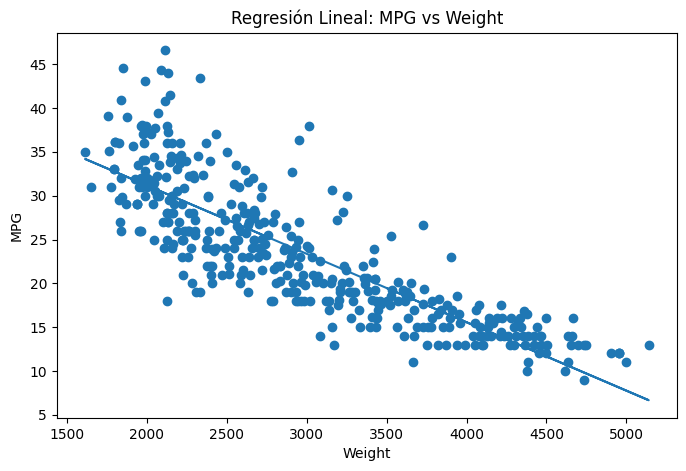

In [13]:
y_pred = model.predict(X)

plt.figure(figsize=(8,5))
plt.scatter(X, y)
plt.plot(X, y_pred)
plt.xlabel("Weight")
plt.ylabel("MPG")
plt.title("Regresión Lineal: MPG vs Weight")
plt.show()

¿Qué observan?
¿La relación parece lineal?

1. Relación claramente negativa: A mayor peso → menor MPG
    Eso ya valida la intuición física.

2. La relación parece bastante lineal: No vemos una curva clara.
    La tendencia dominante es lineal decreciente.

3. Hay dispersión alrededor de la recta
   * Peso explica parte del MPG…
   * pero claramente no todo.

7. Evaluar con R² y MAE

In [14]:
from sklearn.metrics import r2_score, mean_absolute_error

y_test_pred = model.predict(X_test)

r2 = r2_score(y_test, y_test_pred)
mae = mean_absolute_error(y_test, y_test_pred)

print("R2:", r2)
print("MAE:", mae)

R2: 0.722971057303075
MAE: 3.1177861992064573


8. Interpretar el coeficiente de regresión

* ¿Qué significa R² = 0.72?
    El modelo explica aproximadamente el 72% de la variabilidad del MPG usando solo el peso.
    
    El peso es un predictor fuerte del consumo, pero no lo explica todo.

* ¿Qué significa MAE = 3.12?

    En promedio, el modelo se equivoca en:≈ 3.1 millas por galón.

* ¿Ese error es grande o pequeño? ... Depende del contexto.

    Si el rango del MPG va de: ~10 a ~45

    Un error promedio de 3 puede ser razonable.

La regresión lineal logró capturar gran parte del comportamiento del MPG usando solo el peso. Sin embargo, el 28% de la variabilidad sigue sin explicarse, lo que sugiere que existen otros factores relevantes.

9. Aplicamos Cross-Validation (k=5)

In [15]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

model = LinearRegression()

# Validación cruzada con 5 folds
r2_scores = cross_val_score(model, X, y, cv=5, scoring='r2')

print("R2 por fold:", r2_scores)
print("R2 promedio:", np.mean(r2_scores))
print("Desviación estándar:", np.std(r2_scores))

R2 por fold: [ 0.43423842  0.35261673  0.79584633  0.68501427 -0.7082704 ]
R2 promedio: 0.31188907099100277
Desviación estándar: 0.5349374725542042


Primero: Tu split 80/20 dio R² ≈ 0.72.

Pero la validación cruzada dice:

* R² promedio ≈ 0.31
* Desviación estándar ≈ 0.53
* Un fold con R² negativo (-0.70)
(R² negativo significa:El modelo predice peor que simplemente usar la media.)

**Interpretación**

* El modelo no es estable.

* Funciona bien en algunos subconjuntos, pero muy mal en otros.

Eso puede indicar:
1. Alta sensibilidad a la distribución de los datos
2. Posible heterogeneidad en el dataset
3. Relación no perfectamente lineal
4. Que el train/test 80/20 fue “optimista”

Un solo split puede engañar.

La validación cruzada revela estabilidad o fragilidad.

Un modelo puede verse sólido en un split, pero inestable cuando se evalúa de forma más rigurosa.

10. K-Fold Cross Validation (Usa KFold con shuffle=True)

In [16]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')

print(r2_scores)
print("Promedio:", r2_scores.mean())
print("Std:", r2_scores.std())

[0.72297106 0.68883619 0.69029271 0.66528104 0.68379237]
Promedio: 0.690234672169334
Std: 0.018643054021819355


¿Qué pasó entonces?

Antes se uso KFold sin shuffle=True.

Eso significa que el dataset se dividió por bloques, respetando el orden original.

Y este dataset está ordenado por año/modelo.

Entonces probablemente ocurrió algo como esto:

* Fold 1 → autos antiguos
* Fold 2 → mezcla
* Fold 3 → más nuevos
* Fold 4 → otra mezcla
* Fold 5 → extremos

Eso rompe la homogeneidad entre folds.

No porque el dataset esté estratificado. Sino porque está ordenado.

El problema no era el modelo.

Era la forma en que dividimos los datos.

Cuando se activo shuffle=True:

* Las observaciones se distribuyeron aleatoriamente
* Cada fold tuvo mezcla representativa
* El rendimiento se estabilizó

Y ahora el promedio (0.69) está muy cerca del 80/20 original (~0.72).

Eso es coherente.

10. Conclusiones

La regresión lineal simple utilizando únicamente el peso del vehículo como predictor logra explicar aproximadamente el 69% de la variabilidad del MPG, y lo hace de forma estable cuando se evalúa mediante validación cruzada con barajado de datos. Esto confirma que el peso es un factor estructuralmente relevante en la eficiencia de combustible, aunque no la explica por completo. Además, la comparación entre distintos esquemas de validación demuestra que la forma en que dividimos los datos influye directamente en la percepción del desempeño del modelo. En consecuencia, no solo importa el algoritmo, sino también la estrategia de evaluación utilizada para estimar su capacidad de generalización.

El modelo simple MPG ~ Weight:

* Tiene R² ≈ 0.69 en promedio
* Es estable (std ≈ 0.018 es muy bajo)
* Generaliza razonablemente bien

## Ejercicio 1

1. Cargar el dataset bicicletas.csv



In [17]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 250

peso = np.random.normal(12, 1.5, n)  # kg
tamano_cuadro = np.random.choice(["S", "M", "L"], n)
marchas = np.random.choice([7, 14, 18, 21, 24], n)
tipo = np.random.choice(["Ruta", "Montaña", "Urbana"], n)

# Relación de precio simulada
precio = (
    300
    + peso * -20
    + marchas * 25
    + np.where(tipo == "Montaña", 400, 0)
    + np.where(tipo == "Ruta", 600, 0)
    + np.random.normal(0, 150, n)
)

df = pd.DataFrame({
    "precio": precio.round(2),
    "peso": peso.round(2),
    "tamano_cuadro": tamano_cuadro,
    "marchas": marchas,
    "tipo": tipo
})

df.head()

,precio,peso,tamano_cuadro,marchas,tipo
0,965.69,12.75,S,21,Ruta
1,527.46,11.79,S,14,Montaña
2,880.49,12.97,S,21,Montaña
3,1108.64,14.28,S,21,Montaña
4,1005.50,11.65,L,24,Urbana


2. Explorar y limpiar los datos si es necesario

In [18]:
df["tipo"].value_counts()

tipo
Ruta       89
Urbana     83
Montaña    78
Name: count, dtype: int64

In [19]:
df["tamano_cuadro"].value_counts()

tamano_cuadro
S    103
L     75
M     72
Name: count, dtype: int64

3. Definir X (variables predictoras) & y (precio)

In [20]:
X = df.drop("precio", axis=1)
y = df["precio"]

4. Separar en conjunto de entrenamiento y prueba

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

5. Entrenar el modelo con LinearRegression

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression

num_cols = ["peso", "marchas"]
cat_cols = ["tamano_cuadro", "tipo"]

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first"), cat_cols) # drop="first" De cada grupo de categorías, una se elimina y se convierte en referencia.
    # Para evitar problemas de colinealidad.
])
#Pipeline significa:
# Paso 1 → Transformar
# Paso 2 → Entrenar modelo
model = Pipeline([
    ("prep", preprocess),
    ("reg", LinearRegression())
])

In [23]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

6. Obten e interpreta los coeficientes

In [24]:
coef = model.named_steps["reg"].coef_  # Extraer los coeficientes del modelo
feature_names = model.named_steps["prep"].get_feature_names_out() # Obtener los nombres reales de las variables
pd.Series(coef, index=feature_names).sort_values() # Unir coeficientes con nombres

cat__tipo_Urbana       -388.003726
num__peso               -32.086484
cat__tamano_cuadro_M     27.132087
cat__tamano_cuadro_S     37.058243
num__marchas            154.702662
cat__tipo_Ruta          200.173521
dtype: float64

In [25]:
intercepto = model.named_steps["reg"].intercept_
print("Intercepto:", intercepto)

Intercepto: 867.5364104464762


In [26]:
print("Intercepto:", intercepto)

for name, c in zip(feature_names, coef):
    print(f"{name}: {c}")

Intercepto: 867.5364104464762
num__peso: -32.08648367653515
num__marchas: 154.70266183845084
cat__tamano_cuadro_M: 27.132087351540576
cat__tamano_cuadro_S: 37.058243081717535
cat__tipo_Ruta: 200.1735212039878
cat__tipo_Urbana: -388.00372627306496


7. Realiza predicciones sobre el set de prueba

In [27]:
y_pred = model.predict(X_test)

8. Evalúa el rendimiento con R² y MAE

In [28]:
from sklearn.metrics import r2_score, mean_absolute_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R2:", r2)
print("MAE:", mae)

R2: 0.7656410376806493
MAE: 126.17784347474714


9. Visualiza precios reales v/s predichos

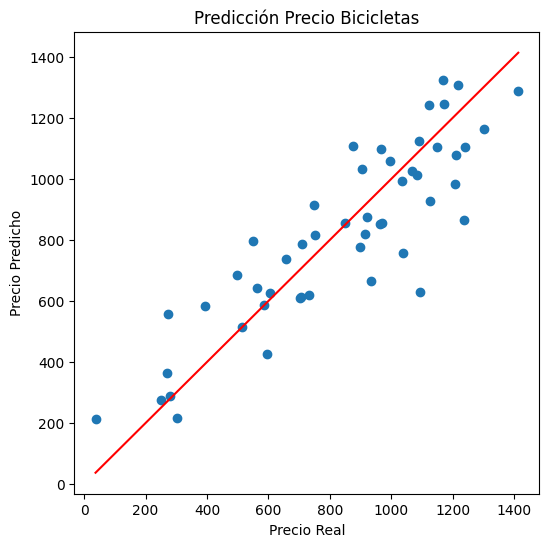

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Predicción Precio Bicicletas")
plt.show()

10. Reflexión: ¿el modelo es útil para el negocio?

R² = 0.756

Eso significa que el modelo explica aproximadamente el 75.6% de la variabilidad del precio.

En términos simples:

El 75% del comportamiento del precio se puede explicar por peso, marchas, tipo y tamaño.

MAE = 126.17

Aquí está lo realmente interesante.

El MAE es el error promedio absoluto.

Eso significa:

En promedio, te equivocas en aproximadamente 126 unidades monetarias.

**¿Es 126 mucho o poco?**

In [30]:
y.min(), y.max()

(np.float64(37.07), np.float64(1634.96))

Rango de precios:
1634.96 - 37.07 = 1597.89

Error promedio:
126.18

proporción del rango total : 126.18/1597.89 = 0.079 => 7.9%

In [31]:
y.mean()

np.float64(829.96204)

126.18 / 829.96 = 15.20%

En promedio, el modelo se equivoca en 15% del precio promedio.



11. Validación Cruzada

In [32]:
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores = cross_val_score(model, X, y, cv=kf, scoring="r2")

print("R2 por fold:", r2_scores)
print("R2 promedio:", np.mean(r2_scores))
print("Desviación estándar:", np.std(r2_scores))

R2 por fold: [0.76564104 0.83433052 0.66197539 0.76432911 0.73154396]
R2 promedio: 0.7515640052638861
Desviación estándar: 0.055925538302233985


1. El promedio es casi igual al R² que obtuviste antes (~0.75).
Eso significa que tu train/test inicial no fue suerte.

2. No hay ningún fold negativo.
Eso es buena señal. El modelo generaliza.

3. La desviación estándar es baja (~0.056).
Eso indica estabilidad. No está cambiando dramáticamente según la partición.

In [33]:
mae_scores = -cross_val_score(
    model, X, y,
    cv=kf,
    scoring="neg_mean_absolute_error"
)

print("MAE por fold:", mae_scores)
print("MAE promedio:", np.mean(mae_scores))
print("Desviación estándar:", np.std(mae_scores))

MAE por fold: [126.17784347 116.62049016 147.74479912 136.32672611 125.76081259]
MAE promedio: 130.52613429321215
Desviación estándar: 10.631200745281717


1. El error es consistente

La desviación estándar (~10)

 es baja respecto al promedio (~130).

Eso significa:

* El modelo no se comporta dramáticamente distinto según la partición.
* Es estable.

2. El error relativo sigue siendo ~15%

Recordando que el precio promedio era ~830.
* 130/830≈15.6%

Eso confirma lo que ya habíamos visto.

El modelo predice con un error promedio cercano al 15%.

3. Fold 3 tuvo mayor error (~147)

* Pero no es extremo.
* No hay fold donde el error se dispare.
* Eso es buena señal de generalización.

**Conclusión global**

El modelo de regresión lineal múltiple logra explicar aproximadamente el 75% de la variabilidad del precio de las bicicletas y lo hace de manera estable bajo validación cruzada, lo que confirma que no depende de una partición específica de los datos. El error promedio se sitúa en torno a 130 unidades monetarias, equivalente a cerca del 15% del precio promedio, lo que indica que el modelo captura bien la estructura general del problema, aunque aún existe variabilidad no explicada. En términos prácticos, el modelo es útil para estimaciones razonables y análisis comparativos, pero podría perfeccionarse incorporando variables adicionales o técnicas más complejas si se requiere mayor precisión.

## PARTE 2

In [34]:
X.dtypes

peso             float64
tamano_cuadro     object
marchas            int64
tipo              object
dtype: object

In [35]:
# Separar numéricas y categóricas para evitar el error en modelos que no manejan variables categóricas
X_num = X.select_dtypes(include=['int64', 'float64'])
X_cat = X.select_dtypes(include=['object', 'string'])


In [36]:
# Comparación de modelos
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
import numpy as np
# Modelo lineal
modelo_lineal = LinearRegression()
mse_lineal = -cross_val_score(modelo_lineal, X_num, y, cv=5, scoring='neg_mean_squared_error')
# Modelo polinómico
modelo_poli = Pipeline([    ('poly', PolynomialFeatures(degree=2)),
                            ('linear', LinearRegression())])
mse_poli = -cross_val_score(modelo_poli, X_num, y, cv=5, scoring='neg_mean_squared_error')
print(f"MSE modelo lineal: {np.mean(mse_lineal):.2f}")
print(f"MSE modelo polinómico: {np.mean(mse_poli):.2f}")

MSE modelo lineal: 91595.76
MSE modelo polinómico: 93051.44
